# Engenharia de Features
Este notebook tem como objetivo:
- Definir estratégia inicial de modelagem a partir dos dados brutos analisados em eda.ipynb
- Criar e tratar variáveis explicativas
- Definir e tratar a variável alvo
- Garantir que as variáveis explicativas sejam claras e de fácil explicação para stakeholders

# Setup

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

### Leitura de dados

In [102]:
df_unica = pd.read_csv('Data/processed/base_modelagem.csv')
df_unica['data'] = pd.to_datetime(df_unica['data'])
df_unica = df_unica.sort_values(by=['codigo_filial', 'data'])
df_unica.head()

,codigo_filial,data,faturamento,quantidade,quantidade_tickets,faturamento_medio_ticket,meta_n_med,faixa_vida,localidade,uf,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas,evento
0,1500,2025-01-01,18077.83704,828.0,138.0,130.998819,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.0388,NÃO,NÃO,NÃO,Confraternização mundial
1,1500,2025-01-02,18077.83704,828.0,138.0,130.998819,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.0388,NÃO,NÃO,NÃO,Dia Comum
2,1500,2025-01-03,29631.50298,1107.0,188.0,157.614378,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.0388,NÃO,NÃO,NÃO,Dia Comum
3,1500,2025-01-04,14137.64100,597.0,98.0,144.261643,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.0388,NÃO,NÃO,NÃO,Dia Comum
4,1500,2025-01-05,18077.83704,828.0,138.0,130.998819,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.0388,NÃO,NÃO,NÃO,Dia Comum


# Criação de features
Estratégia inicial de modelagem:
- A sazonalidade anual será descartada por termos apenas 1 ano de dados de treino.
    - Apesar disso ainda temos os ciclos semanais e mensais.
    - Datas como black friday e natal serão um desafio de modelagem, já que o modelo não terá um mínimo de dois ciclos pra aprender o padrão.
    - ***Será adotada a meta padrão (meta_n_med) como BASELINE e Feature**

- Considerando o tamanho do dataset, a preferência dos modelos vai girar em torno de **modelos globais**, deixando de lado opões como a família ARIMA e o Prophet.
    - As features serão criadas com isso em mente.


## Features de filiais
- Transformação de features relacionadas a filias (ex. delivery, panvel_clinic, etc) em binário
- Inclui também tipos de estabelecimento como dummies

In [103]:
df_model = df_unica.copy()

# Binariza colunas SIM/NÃO
cols_sim_nao = ['delivery', 'panvel_clinic', 'estacionamento', 'atendimento_24_horas']
for col in cols_sim_nao:
    df_model[col] = df_model[col].map({'SIM': 1, 'NÃO': 0, 'Sim': 1, 'Não': 0, 'sim': 1, 'não': 0})

# Mapeia a coluna faixa_vida para valores numéricos
mapa_faixa_vida = {
    'MENOS DE 1 ANO': 0,
    'ENTRE 1-2 ANOS': 1,
    'ENTRE 2-3 ANOS': 1,
    'MAIS DE 3 ANOS': 2
}
df_model['faixa_vida'] = df_model['faixa_vida'].map(mapa_faixa_vida)

# Remove coluna sem variância
if 'uf' in df_model.columns:
    df_model = df_model.drop(columns=['uf'])

# TARGET ENCODING DINÂMICO (Localidade + Tipo)
df_group = df_model.groupby(['localidade', 'tipo_estabelecimento', 'data'])['faturamento'].mean().reset_index(name='fat_medio_grupo')
df_group = df_group.sort_values(by=['localidade', 'tipo_estabelecimento', 'data'])

# Calcula as médias móveis
df_group['local_tipo_mm7'] = df_group.groupby(['localidade', 'tipo_estabelecimento'])['fat_medio_grupo'].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
df_group['local_tipo_mm15'] = df_group.groupby(['localidade', 'tipo_estabelecimento'])['fat_medio_grupo'].transform(lambda x: x.shift(1).rolling(15, min_periods=1).mean())
df_group['local_tipo_mm30'] = df_group.groupby(['localidade', 'tipo_estabelecimento'])['fat_medio_grupo'].transform(lambda x: x.shift(1).rolling(30, min_periods=1).mean())

# Remove a coluna auxiliar une de volta a tabela
df_group = df_group.drop(columns=['fat_medio_grupo'])
df_model = pd.merge(df_model, df_group, on=['localidade', 'tipo_estabelecimento', 'data'], how='left')

# Descarta a coluna original de texto
df_model = df_model.drop(columns=['localidade'])

# ONE-HOT ENCODING
df_model['tipo_estabelecimento_copy'] = df_model['tipo_estabelecimento']
df_model = pd.get_dummies(df_model, columns=['tipo_estabelecimento_copy'])

## Clusterização de filiais por padrão de comportamento
- Criação de clusters de filiais por padrão de faturamento e comportamento.
- Clusterização ok, mas a filial 1521 pode ser removida por ser fora da curva.
    - Duas opções: Manter ela no cluster 3 ou desenvolver uma previsão individual.
- Desconsidera meses 11 e 12 (dados de teste)

In [104]:
# Apenas dados de treino
filtro_teste = (df_model['data'].dt.month.isin([1,2,3]))
df_treino = df_model[filtro_teste].copy()

# Extração de estatísticas globais da série de cada filial
df_perfil = df_treino.groupby('codigo_filial').agg(
    fat_medio=('faturamento', 'mean'),
    fat_desvio=('faturamento', 'std')
).reset_index()

# O Coeficiente de Variação normaliza a volatilidade (lojas de pico vs lojas estáveis)
df_perfil['coef_variacao'] = df_perfil['fat_desvio'] / df_perfil['fat_medio']

# Criação da feature temporal: peso do final de semana no faturamento da loja
df_treino['is_weekend'] = df_treino['data'].dt.dayofweek.isin([5, 6]).astype(int)
df_model['is_weekend'] = df_model['data'].dt.dayofweek.isin([5, 6]).astype(int)

peso_fds = df_treino.groupby('codigo_filial').apply(
    lambda x: x[x['is_weekend'] == 1]['faturamento'].mean() / (x[x['is_weekend'] == 0]['faturamento'].mean() + 1e-9)
).reset_index(name='razao_fds')

df_perfil = df_perfil.merge(peso_fds, on='codigo_filial')

# Preparação e padronização dos dados para o K-Means não ser enviesado pela escala financeira
features_cluster = ['fat_medio', 'coef_variacao', 'razao_fds']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_perfil[features_cluster].fillna(0))

# Definição inicial de 4 perfis de comportamento (ex: Alto Volume/Estável, Baixo Volume/Volátil, etc.)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_perfil['cluster_comportamento'] = kmeans.fit_predict(X_scaled)

# Integração da nova feature à tabela analítica
df_model = df_model.merge(df_perfil[['codigo_filial', 'cluster_comportamento']], on='codigo_filial', how='left')
df_treino = df_treino.merge(df_perfil[['codigo_filial', 'cluster_comportamento']], on='codigo_filial', how='left')

# Distribuição
print(df_model.groupby('codigo_filial')['cluster_comportamento'].mean().value_counts())

cluster_comportamento
4.0    54
3.0    36
0.0    21
2.0     1
1.0     1
Name: count, dtype: int64


In [105]:
# Agrupamento geral por cluster
analise_clusters = df_perfil.groupby('cluster_comportamento').agg({
    'fat_medio': 'mean',
    'fat_desvio': 'mean',
    'coef_variacao': 'mean',
    'codigo_filial': 'count'
}).rename(columns={'codigo_filial': 'qtd_filiais'}).round(4)

print(analise_clusters)

                         fat_medio  fat_desvio  coef_variacao  qtd_filiais
cluster_comportamento                                                     
0                       39548.9837   7787.9123         0.1957           21
1                        6437.0056   8398.1808         1.3047            1
2                      119833.3345  25188.2375         0.2102            1
3                       18160.7401   4409.9601         0.2459           36
4                       19809.3212   5107.6141         0.2618           54


In [117]:
df_perfil[df_perfil['cluster_comportamento'].isin([2, 1])]

,codigo_filial,fat_medio,fat_desvio,coef_variacao,razao_fds,cluster_comportamento
7,1521,119833.334510,25188.237457,0.210194,0.746884,2
112,1857,6437.005558,8398.180823,1.304672,0.909950,1


## Features derivadas do target e autocorrelação
- Verificação das autocorrelações por cluster de filial
- Os lags mais importantes vão virar features

Top 5 Lags por Cluster:

*** Cluster 0 ***
Top 5 ACF:  [7, 1]
Top 5 PACF: [7, 1]

*** Cluster 1 ***
Top 5 ACF:  [1, 2, 3, 4, 5]
Top 5 PACF: [1]

*** Cluster 2 ***
Top 5 ACF:  [7, 1]
Top 5 PACF: [1, 7, 8]

*** Cluster 3 ***
Top 5 ACF:  [7, 1]
Top 5 PACF: [7, 8, 1]

*** Cluster 4 ***
Top 5 ACF:  [7]
Top 5 PACF: [7, 8, 1]

*** CONSOLIDAÇÃO GLOBAL ***
Lista Final ACF:  [1, 2, 3, 4, 5, 7]
Lista Final PACF: [1, 7, 8]


C:\Users\User\AppData\Local\Temp\ipykernel_19704\801560039.py:81: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


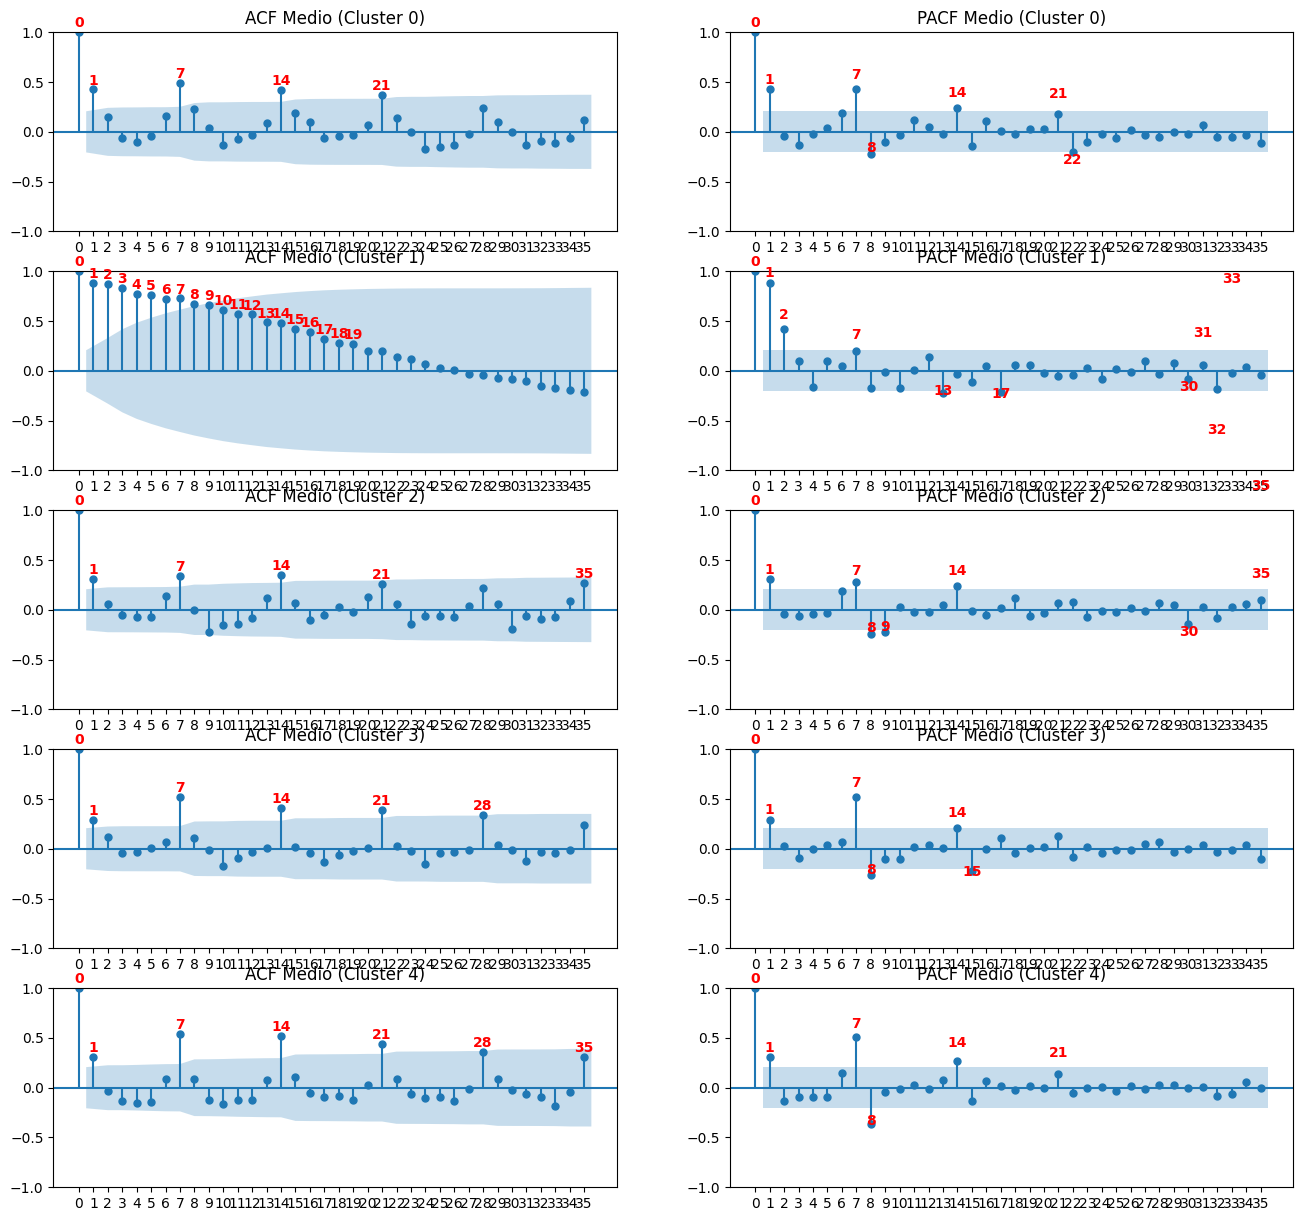

In [107]:
# Agrupamento do faturamento médio diário por cluster
df_cluster_acf = df_treino.groupby(['cluster_comportamento', 'data'])['faturamento'].mean().reset_index()
clusters_unicos = sorted(df_cluster_acf['cluster_comportamento'].dropna().unique())

fig, axes = plt.subplots(len(clusters_unicos), 2, figsize=(16, 3 * len(clusters_unicos)))

# Ajuste dimensional caso exista apenas um cluster ativo
if len(clusters_unicos) == 1:
    axes = np.array([axes])

for i, cluster in enumerate(clusters_unicos):
    df_plot = df_cluster_acf[df_cluster_acf['cluster_comportamento'] == cluster].sort_values('data').set_index('data')
    ts = df_plot['faturamento'].dropna()
    
    valores_acf = acf(ts, nlags=35)
    valores_pacf = pacf(ts, nlags=35)
    
    plot_acf(ts, lags=35, ax=axes[i, 0], title=f'ACF Medio (Cluster {cluster})')
    plot_pacf(ts, lags=35, ax=axes[i, 1], title=f'PACF Medio (Cluster {cluster})')
    
    for lag, val in enumerate(valores_acf):
        if abs(val) > 0.25:
            axes[i, 0].text(lag, val + 0.05, f'{lag}', color='red', ha='center', fontweight='bold')
            
    for lag, val in enumerate(valores_pacf):
        if abs(val) > 0.25:
            axes[i, 1].text(lag, val + 0.05, f'{lag}', color='red', ha='center', fontweight='bold')
            
    axes[i, 0].set_xticks(range(0, 36))
    axes[i, 1].set_xticks(range(0, 36))

# Dicionario com os lags relevantes para cada cluster
dicionario_lags = {}

for cluster in clusters_unicos:
    df_plot = df_cluster_acf[df_cluster_acf['cluster_comportamento'] == cluster].sort_values('data').set_index('data')
    ts = df_plot['faturamento'].dropna()
    
    valores_acf = acf(ts, nlags=35)
    valores_pacf = pacf(ts, nlags=35)
    
    # Mapeamento do lag para a sua magnitude exata
    lags_acf_relevantes = {lag: round(float(val), 3) for lag, val in enumerate(valores_acf) if abs(val) > 0.25 and lag > 0}
    lags_pacf_relevantes = {lag: round(float(val), 3) for lag, val in enumerate(valores_pacf) if abs(val) > 0.25 and lag > 0}
    
    dicionario_lags[f'Cluster {cluster}'] = {
        'acf': lags_acf_relevantes,
        'pacf': lags_pacf_relevantes
    }

lags_importantes_acf = set()
lags_importantes_pacf = set()

# Cria a lista dos lags que vão virar features
print("Top 5 Lags por Cluster:\n")
for cluster, valores in dicionario_lags.items():
    # Ordena os lags pela magnitude absoluta do sinal de forma decrescente
    top_5_acf = sorted(valores['acf'].items(), key=lambda x: abs(x[1]), reverse=True)[:5]
    top_5_pacf = sorted(valores['pacf'].items(), key=lambda x: abs(x[1]), reverse=True)[:5]
    
    # Isola apenas os dias (chaves)
    lags_acf = [lag for lag, valor in top_5_acf if lag < 10]
    lags_pacf = [lag for lag, valor in top_5_pacf if lag < 10]
    
    print(f"*** {cluster} ***")
    print(f"Top 5 ACF:  {lags_acf}")
    print(f"Top 5 PACF: {lags_pacf}\n")
    
    # Insere no conjunto para evitar duplicidade na lista final
    lags_importantes_acf.update(lags_acf)
    lags_importantes_pacf.update(lags_pacf)

# Transforma os conjuntos em listas ordenadas
lags_importantes_acf = sorted(list(lags_importantes_acf))
lags_importantes_pacf = sorted(list(lags_importantes_pacf))

print("*** CONSOLIDAÇÃO GLOBAL ***")
print(f"Lista Final ACF:  {lags_importantes_acf}")
print(f"Lista Final PACF: {lags_importantes_pacf}")

plt.tight_layout()
plt.show()

In [108]:
# Criação de features dinâmicas a partir da análise de correlação
df_model = df_model.sort_values(by=['codigo_filial', 'data'])

# Criação de Lags diretos para os dias de forte impacto isolado (PACF)
for lag in [x for x in lags_importantes_pacf if x!=1]:
    df_model[f'fat_lag_{lag}'] = df_model.groupby('codigo_filial')['faturamento'].shift(lag - 1)

# Criação de Médias Móveis para os ciclos de memória acumulada (ACF)
for janela in [x for x in lags_importantes_acf if x!=1]:
    df_model[f'fat_mm_{janela}'] = df_model.groupby('codigo_filial')['faturamento'].transform(
        lambda x: x.rolling(window=janela, min_periods=1).mean()
    )

In [109]:
df_model.head()

,codigo_filial,data,faturamento,quantidade,quantidade_tickets,faturamento_medio_ticket,meta_n_med,faixa_vida,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas,evento,local_tipo_mm7,local_tipo_mm15,local_tipo_mm30,tipo_estabelecimento_copy_BAIRRO,tipo_estabelecimento_copy_CENTRO,tipo_estabelecimento_copy_MALL,tipo_estabelecimento_copy_SHOPPING,is_weekend,cluster_comportamento,fat_lag_7,fat_lag_8,fat_mm_2,fat_mm_3,fat_mm_4,fat_mm_5,fat_mm_7
0,1500,2025-01-01,18077.83704,828.0,138.0,130.998819,12732.76,2,CENTRO,0,309.0388,0,0,0,Confraternização mundial,NaN,NaN,NaN,False,True,False,False,0,4,NaN,NaN,18077.83704,18077.83704,18077.837040,18077.837040,18077.837040
1,1500,2025-01-02,18077.83704,828.0,138.0,130.998819,12732.76,2,CENTRO,0,309.0388,0,0,0,Dia Comum,19189.083578,19189.083578,19189.083578,False,True,False,False,0,4,NaN,NaN,18077.83704,18077.83704,18077.837040,18077.837040,18077.837040
2,1500,2025-01-03,29631.50298,1107.0,188.0,157.614378,12732.76,2,CENTRO,0,309.0388,0,0,0,Dia Comum,20767.440004,20767.440004,20767.440004,False,True,False,False,0,4,NaN,NaN,23854.67001,21929.05902,21929.059020,21929.059020,21929.059020
3,1500,2025-01-04,14137.64100,597.0,98.0,144.261643,12732.76,2,CENTRO,0,309.0388,0,0,0,Dia Comum,24959.255010,24959.255010,24959.255010,False,True,False,False,1,4,NaN,NaN,21884.57199,20615.66034,19981.204515,19981.204515,19981.204515
4,1500,2025-01-05,18077.83704,828.0,138.0,130.998819,12732.76,2,CENTRO,0,309.0388,0,0,0,Dia Comum,24043.300802,24043.300802,24043.300802,False,True,False,False,1,4,NaN,NaN,16107.73902,20615.66034,19981.204515,19600.531020,19600.531020


## Features de calendário
- Transformação de data em informação cíclica (seno e cosseno)
- Codificação de feriados e preparação de feriados

In [110]:
# Base de calendário 
df_model['dia_do_mes'] = df_model['data'].dt.day
df_model['dia_da_semana'] = df_model['data'].dt.dayofweek
df_model['semana_do_mes'] = (df_model['data'].dt.day - 1) // 7 + 1
df_model['is_pagamento'] = df_model['dia_do_mes'].apply(lambda x: 1 if 5 <= x <= 10 else 0)

# Transformações Cíclicas - Ciclo Semanal
df_model['sin_dia_semana'] = np.sin(2 * np.pi * df_model['dia_da_semana'] / 7)
df_model['cos_dia_semana'] = np.cos(2 * np.pi * df_model['dia_da_semana'] / 7)

# Transformações Cíclicas - Ciclo Mensal (dinâmico pelo tamanho exato do mês)
dias_no_mes = df_model['data'].dt.days_in_month
df_model['sin_dia_mes'] = np.sin(2 * np.pi * df_model['dia_do_mes'] / dias_no_mes)
df_model['cos_dia_mes'] = np.cos(2 * np.pi * df_model['dia_do_mes'] / dias_no_mes)

# Flag de Feriado baseada na coluna original de eventos
df_model['is_feriado'] = (df_model['evento'] != 'Dia Comum').astype(int)

# Captura de Véspera de Feriado (antecipação de consumo)
df_model = df_model.sort_values(by=['codigo_filial', 'data'])
df_model['vespera_feriado'] = df_model.groupby('codigo_filial')['is_feriado'].shift(-1).fillna(0).astype(int)

# Captura de Semana com Feriado (impacto estendido)
df_model['is_semana_feriado'] = df_model['is_feriado'].replace(0, np.nan)
df_model['is_semana_feriado'] = df_model.groupby('codigo_filial')['is_semana_feriado'].bfill(limit=7).fillna(0).astype(int)

# Limpeza de colunas de texto que não servem mais para o modelo
df_model = df_model.drop(columns=['evento'])

## Features de Meta e quantidade

In [111]:
# Volume físico de produtos: memória exata da semana anterior e tendência suave
df_model['qtd_lag_7'] = df_model.groupby('codigo_filial')['quantidade'].shift(6) # O target é shift(-1), então o lag de 7 é shift(6)
df_model['qtd_mm_7'] = df_model.groupby('codigo_filial')['quantidade'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# Variação de preço médio para entender se a loja está vendendo itens mais caros
df_model['preco_medio_item'] = df_model['faturamento'] / df_model['quantidade'].replace(0, np.nan)
df_model['preco_medio_mm_7'] = df_model.groupby('codigo_filial')['preco_medio_item'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)
df_model['preco_medio_mm_30'] = df_model.groupby('codigo_filial')['preco_medio_item'].transform(
    lambda x: x.rolling(window=30, min_periods=1).mean()
)
df_model = df_model.drop(columns=['preco_medio_item'])

# Fluxo de clientes (tickets): captura o movimento na farmácia isolando o valor financeiro
df_model['tickets_lag_7'] = df_model.groupby('codigo_filial')['quantidade_tickets'].shift(6)
df_model['tickets_mm_7'] = df_model.groupby('codigo_filial')['quantidade_tickets'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)
df_model['tickets_mm_30'] = df_model.groupby('codigo_filial')['quantidade_tickets'].transform(
    lambda x: x.rolling(window=30, min_periods=1).mean()
)

# Avalia o nível de agressividade do planejamento comparando o faturamento recente com a meta
df_model['atingimento_diario'] = df_model['faturamento'] / df_model['meta_n_med'].replace(0, np.nan)
df_model['vies_meta_mm_7'] = df_model.groupby('codigo_filial')['atingimento_diario'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)
df_model = df_model.drop(columns=['atingimento_diario'])

# Meta de hoje e de ontem
df_model['meta_n_med_tgt'] = df_model['meta_n_med'].shift(-1)

# Desloca a variável alvo para o dia de amanhã e limpa os vazios gerados no fim da série
df_model['target'] = df_model.groupby('codigo_filial')['faturamento'].shift(-1)
df_model = df_model.dropna(subset=['target'])

In [112]:
df_model.head(10)

,codigo_filial,data,faturamento,quantidade,quantidade_tickets,faturamento_medio_ticket,meta_n_med,faixa_vida,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas,local_tipo_mm7,local_tipo_mm15,local_tipo_mm30,tipo_estabelecimento_copy_BAIRRO,tipo_estabelecimento_copy_CENTRO,tipo_estabelecimento_copy_MALL,tipo_estabelecimento_copy_SHOPPING,is_weekend,cluster_comportamento,fat_lag_7,fat_lag_8,fat_mm_2,fat_mm_3,fat_mm_4,fat_mm_5,fat_mm_7,dia_do_mes,dia_da_semana,semana_do_mes,is_pagamento,sin_dia_semana,cos_dia_semana,sin_dia_mes,cos_dia_mes,is_feriado,vespera_feriado,is_semana_feriado,qtd_lag_7,qtd_mm_7,preco_medio_mm_7,preco_medio_mm_30,tickets_lag_7,tickets_mm_7,tickets_mm_30,vies_meta_mm_7,meta_n_med_tgt,target
0,1500,2025-01-01,18077.83704,828.0,138.0,130.998819,12732.76,2,CENTRO,0,309.0388,0,0,0,NaN,NaN,NaN,False,True,False,False,0,4,NaN,NaN,18077.837040,18077.83704,18077.837040,18077.837040,18077.837040,1,2,1,0,0.974928,-0.222521,0.201299,0.979530,1,0,1,NaN,828.000000,21.833137,21.833137,NaN,138.000000,138.000000,1.419789,12732.76,18077.83704
1,1500,2025-01-02,18077.83704,828.0,138.0,130.998819,12732.76,2,CENTRO,0,309.0388,0,0,0,19189.083578,19189.083578,19189.083578,False,True,False,False,0,4,NaN,NaN,18077.837040,18077.83704,18077.837040,18077.837040,18077.837040,2,3,1,0,0.433884,-0.900969,0.394356,0.918958,0,0,0,NaN,828.000000,21.833137,21.833137,NaN,138.000000,138.000000,1.419789,12732.76,29631.50298
2,1500,2025-01-03,29631.50298,1107.0,188.0,157.614378,12732.76,2,CENTRO,0,309.0388,0,0,0,20767.440004,20767.440004,20767.440004,False,True,False,False,0,4,NaN,NaN,23854.670010,21929.05902,21929.059020,21929.059020,21929.059020,3,4,1,0,-0.433884,-0.900969,0.571268,0.820763,0,0,0,NaN,921.000000,23.477888,23.477888,NaN,154.666667,154.666667,1.722255,12732.76,14137.64100
3,1500,2025-01-04,14137.64100,597.0,98.0,144.261643,12732.76,2,CENTRO,0,309.0388,0,0,0,24959.255010,24959.255010,24959.255010,False,True,False,False,1,4,NaN,NaN,21884.571990,20615.66034,19981.204515,19981.204515,19981.204515,4,5,1,0,-0.974928,-0.222521,0.724793,0.688967,0,0,0,NaN,840.000000,23.528701,23.528701,NaN,140.500000,140.500000,1.569275,12732.76,18077.83704
4,1500,2025-01-05,18077.83704,828.0,138.0,130.998819,12732.76,2,CENTRO,0,309.0388,0,0,0,24043.300802,24043.300802,24043.300802,False,True,False,False,1,4,NaN,NaN,16107.739020,20615.66034,19981.204515,19600.531020,19600.531020,5,6,1,1,-0.781831,0.623490,0.848644,0.528964,0,0,0,NaN,837.600000,23.189588,23.189588,NaN,140.000000,140.000000,1.539378,22143.91,21558.72465
5,1500,2025-01-06,21558.72465,975.0,166.0,129.871835,22143.91,2,CENTRO,0,309.0388,0,0,0,23277.820648,23277.820648,23277.820648,False,True,False,False,0,4,NaN,NaN,19818.280845,17924.73423,20851.426417,20296.708542,19926.896625,6,0,1,1,0.000000,1.000000,0.937752,0.347305,0,0,0,NaN,860.500000,23.009909,23.009909,NaN,144.333333,144.333333,1.445077,22143.91,25274.68470
6,1500,2025-01-07,25274.68470,969.0,165.0,153.179907,22143.91,2,CENTRO,0,309.0388,0,0,0,23658.757987,23658.757987,23658.757987,False,True,False,False,0,4,18077.83704,NaN,23416.704675,21637.08213,19762.221847,21736.078074,20690.866350,7,1,1,1,0.781831,0.623490,0.988468,0.151428,0,0,0,828.0,876.000000,23.448960,23.448960,138.0,147.285714,147.285714,1.401692,24911.91,23295.19509
7,1500,2025-01-08,23295.19509,999.0,178.0,130.871883,24911.91,2,CENTRO,0,309.0388,0,0,0,24353.231966,24353.231966,24353.231966,False,True,False,False,0,4,18077.83704,18077.83704,24284.939895,23376.20148,22051.610370,20468.816496,21436.203214,8,2,2,1,0.974928,-0.222521,0.998717,-0.050649,0,0,0,828.0,900.428571,23.661157,23.432654,138.0,153.000000,151.125000,1.332451,22143.91,21162.14199
8,1500,2025-01-09,21162.14199,876.0,152.0,139.224618,22143.91,2,CENTRO,0,309.0388,0,0,0,25582.859428,24783.637447,24783.637447,False,True,False,False,0,4,29631.50298,18077.83704,22228.668540,23244.00726,22822.686607,21873.716694,21876.818207,9,3,2,1,0.433884,-0.900969,0.968077,-0.

# Export

In [113]:
df_model.to_csv('Data/processed/base_modelagem_features.csv', index=False)

In [114]:
df_model.isna().sum()

codigo_filial                           0
data                                    0
faturamento                             0
quantidade                              0
quantidade_tickets                      0
faturamento_medio_ticket                0
meta_n_med                              0
faixa_vida                              0
tipo_estabelecimento                    0
delivery                                0
metragem_area_venda                     0
panvel_clinic                           0
estacionamento                          0
atendimento_24_horas                    0
local_tipo_mm7                        113
local_tipo_mm15                       113
local_tipo_mm30                       113
tipo_estabelecimento_copy_BAIRRO        0
tipo_estabelecimento_copy_CENTRO        0
tipo_estabelecimento_copy_MALL          0
tipo_estabelecimento_copy_SHOPPING      0
is_weekend                              0
cluster_comportamento                   0
fat_lag_7                         

In [115]:
df_model.codigo_filial.nunique()

113